In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [17]:
# load data
import pandas as pd
dataset = pd.read_csv("./../data/total_cells.csv")

ehux_d7_cells  = dataset.head(15)
ehux_cells = dataset.tail(15)

ehux_total_time = ehux_cells['Time (days)'].values
ehux_total_density = 1e6*ehux_cells[' Density (1e6/ml)'].values
ehux_d7_total_time = ehux_d7_cells['Time (days)'].values
ehux_d7_total_density = 1e6*ehux_d7_cells[' Density (1e6/ml)'].values

death_dataset = pd.read_csv("./../data/death_percentage.csv")

ehux_death = death_dataset.tail(15)
ehux_d7_death = death_dataset.head(15)


ehux_dead_time = ehux_death['Time (days)']
ehux_dead_density = ehux_death[' Dead percentage '].values*ehux_total_density/100
ehux_d7_dead_time = ehux_d7_death['Time (days)']
ehux_d7_dead_density = ehux_d7_death[' Dead percentage ']*ehux_d7_total_density/100


In [18]:
def monod_model(t, y, params):
    """
    y = [N, P, D]
    params = (mu_max, Ks, Qn, delta)
    """
    N, P, D = y
    mu_max, Ks, Qn, delta = params

    # Convert P to cells/m^3 (as in your model)
    P_m3 = P * 1e6

    # Monod growth
    mu = mu_max * N / (N + Ks)

    dNdt = -Qn * mu * P_m3
    dPdt = mu * P - delta * P
    dDdt = delta * P

    return [dNdt, dPdt, dDdt]

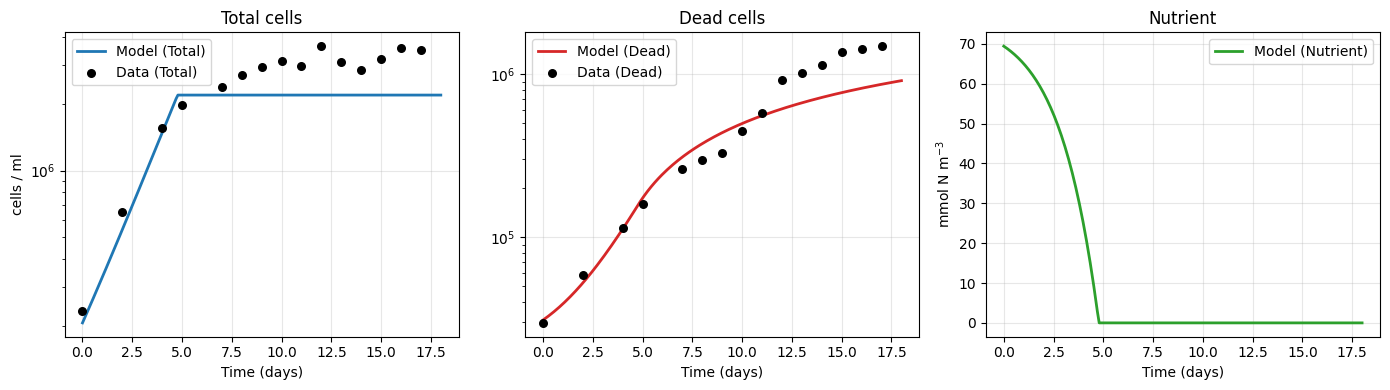

In [44]:

# === Time grid ===
t_eval = np.linspace(0, 18, 200)  # days

factor = 0.1
# === Parameters (EDIT THESE) ===
mu_max = 0.55        # /day
Ks     = 0.1       # mmol/m^3
Qn     = factor*3.5e-10     # mmol N / cell
delta  = 0.035       # /day

params = (mu_max, Ks, Qn, delta)

# === Initial conditions (EDIT THESE) ===
#N0 = factor*2000.0          # mmol/m^3
N0 = 500 + ((1000 / 3.6e-10) * (Qn - 1.9e-10))
P0 = 1.75e5           # cells/ml
D0 = 3.1e4           # cells/ml

y0 = [N0, P0, D0]


sol = solve_ivp(
    fun=lambda t, y: monod_model(t, y, params),
    t_span=(t_eval[0], t_eval[-1]),
    y0=y0,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-6,
    atol=1e-9
)

assert sol.success, sol.message

N, P, D = sol.y
Total = P + D

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)

# --- TOTAL CELLS ---
axes[0].plot(
    t_eval, Total,
    color="tab:blue", lw=2,
    label="Model (Total)"
)
axes[0].scatter(
    ehux_total_time, ehux_total_density,
    color="black", s=30,
    label="Data (Total)", zorder=3
)
axes[0].set_yscale("log")
axes[0].set_title("Total cells")
axes[0].set_ylabel("cells / ml")
axes[0].legend()

# --- DEAD CELLS ---
axes[1].plot(
    t_eval, D,
    color="tab:red", lw=2,
    label="Model (Dead)"
)
axes[1].scatter(
    ehux_dead_time, ehux_dead_density,
    color="black", s=30,
    label="Data (Dead)", zorder=3
)
axes[1].set_yscale("log")
axes[1].set_title("Dead cells")
axes[1].legend()

# --- NUTRIENT ---
axes[2].plot(
    t_eval, N,
    color="tab:green", lw=2,
    label="Model (Nutrient)"
)
axes[2].set_title("Nutrient")
axes[2].set_ylabel("mmol N m$^{-3}$")
axes[2].legend()

# --- Formatting ---
for ax in axes:
    ax.set_xlabel("Time (days)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# load data
dataset = pd.read_csv("./../data/total_cells.csv")

ehux_d7_cells  = dataset.head(15)
ehux_cells = dataset.tail(15)

ehux_total_time = ehux_cells['Time (days)'].values
ehux_total_density = 1e6*ehux_cells[' Density (1e6/ml)'].values
ehux_d7_total_time = ehux_d7_cells['Time (days)'].values
ehux_d7_total_density = 1e6*ehux_d7_cells[' Density (1e6/ml)'].values

death_dataset = pd.read_csv("./../data/death_percentage.csv")

ehux_death = death_dataset.tail(15)
ehux_d7_death = death_dataset.head(15)


ehux_dead_time = ehux_death['Time (days)']
ehux_dead_density = ehux_death[' Dead percentage '].values*ehux_total_density/100
ehux_d7_dead_time = ehux_d7_death['Time (days)']
ehux_d7_dead_density = ehux_d7_death[' Dead percentage ']*ehux_d7_total_density/100





(-9000.0, -7000.0)

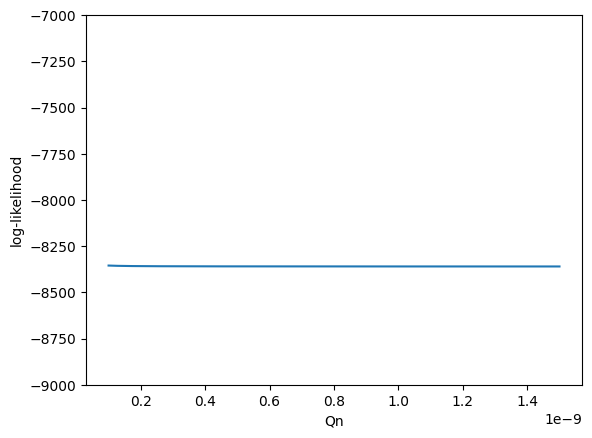

In [40]:
Qn_grid = np.linspace(1e-10, 15e-10, 1000)
loglik = []
times = ehux_total_time
total_obs, dead_obs = ehux_total_density, ehux_dead_density 
sigma_live = 0.1
sigma_dead = 0.2
for Qn in Qn_grid:
    N0 = 500 + ((1000 / 3.6e-10) * (Qn - 1.9e-10))
    
    theta = [mu_max, Ks, Qn, delta]
    y0 = [N0, P0, D0]

    sol = solve_ivp(
        fun=lambda t, y: monod_model(t, y, theta),
        t_span=(times[0], times[-1]),
        y0=y0,
        t_eval=times
    )

    if not sol.success:
        loglik.append(np.nan)
        continue

    total = sol.y[1] + sol.y[2]
    dead = sol.y[2]

    ll = (
        -0.5 * np.sum(((np.log(total_obs) - np.log(total)) / sigma_live)**2)
        -0.5 * np.sum(((np.log(dead_obs)  - np.log(dead))  / sigma_dead)**2)
    )
    loglik.append(ll)

plt.plot(Qn_grid, loglik)
plt.xlabel("Qn")
plt.ylabel("log-likelihood")
plt.ylim(ymin=-9000, ymax=-7000)